**Table of contents**<a id='toc0_'></a>    
- [Simulation output 4 fluorophores no ET](#toc1_)    
  - [Transition set](#toc1_1_)    
  - [Data generation](#toc1_2_)    
    - [Simulation](#toc1_2_1_)    
    - [Save the data](#toc1_2_2_)    
  - [Data processing and visualization](#toc1_3_)    
    - [Read the data](#toc1_3_1_)    
    - [Post-processing](#toc1_3_2_)    
    - [Prediction based on single fluorophore](#toc1_3_3_)    
    - [Figure](#toc1_3_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Simulation output 4 fluorophores no ET](#toc0_)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_1_multi_f_no_et_statistics"

## <a id='toc1_1_'></a>[Transition set](#toc0_)

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=4, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    energy_transfer=False,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

## <a id='toc1_2_'></a>[Data generation](#toc0_)

### <a id='toc1_2_1_'></a>[Simulation](#toc0_)

In [ ]:
rng = np.random.default_rng(1)

simulation = si.Simulation(transition_set)
simulation.run(size=1e6, end_time=2500, seed=rng)

WARNING for line:         warnings.warn(
 Floating point precision error warning:
 The smallest safe increment is 4.55e-13.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1, 1, 1, 1]
 gives a probability of 1.07e-03 for a smaller increment to be drawn. 


### <a id='toc1_2_2_'></a>[Save the data](#toc0_)

In [ ]:
np.save(saving_at + r"\state_series.npy", simulation.state_series)
np.save(saving_at + r"\time_series.npy", simulation.time_series)
np.save(saving_at + r"\transition_series.npy", simulation.transition_series)

## <a id='toc1_3_'></a>[Data processing and visualization](#toc0_)

### <a id='toc1_3_1_'></a>[Read the data](#toc0_)

In [3]:
simulation = si.Simulation(transition_set)
simulation.state_series = np.load(saving_at + r"\state_series.npy")
simulation.time_series = np.load(saving_at + r"\time_series.npy")
simulation.transition_series = np.load(saving_at + r"\transition_series.npy")

### <a id='toc1_3_2_'></a>[Post-processing](#toc0_)

In [4]:
rng = np.random.default_rng(1)
analysis = an.Analysis(simulation)

emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis.extract(simulation)
rt.emission_post_processing(emis=emis, seed=rng)

fcs = fcs_p.FCS(emis)
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink = bl.Blinking(emis)

### <a id='toc1_3_3_'></a>[Prediction based on single fluorophore](#toc0_)

In [5]:
one_fluorophore = fl.construct_fluorophores(name="cy5_dna", count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=one_fluorophore)
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    **rt.PARAMS_DSTORM,
)

transition_set_1f = tr.TransitionSet(transitions, fluorophore_system)
transition_set_1f.finalize()

predict = pr.Prediction(transition_set_1f)

### <a id='toc1_3_4_'></a>[Figure](#toc0_)

prediction is based on different TransitionSet than simulation.
prediction is based on different TransitionSet than simulation.
prediction is based on different TransitionSet than simulation.
prediction is based on different TransitionSet than simulation.
prediction is based on different TransitionSet than simulation.
prediction is based on different TransitionSet than simulation.


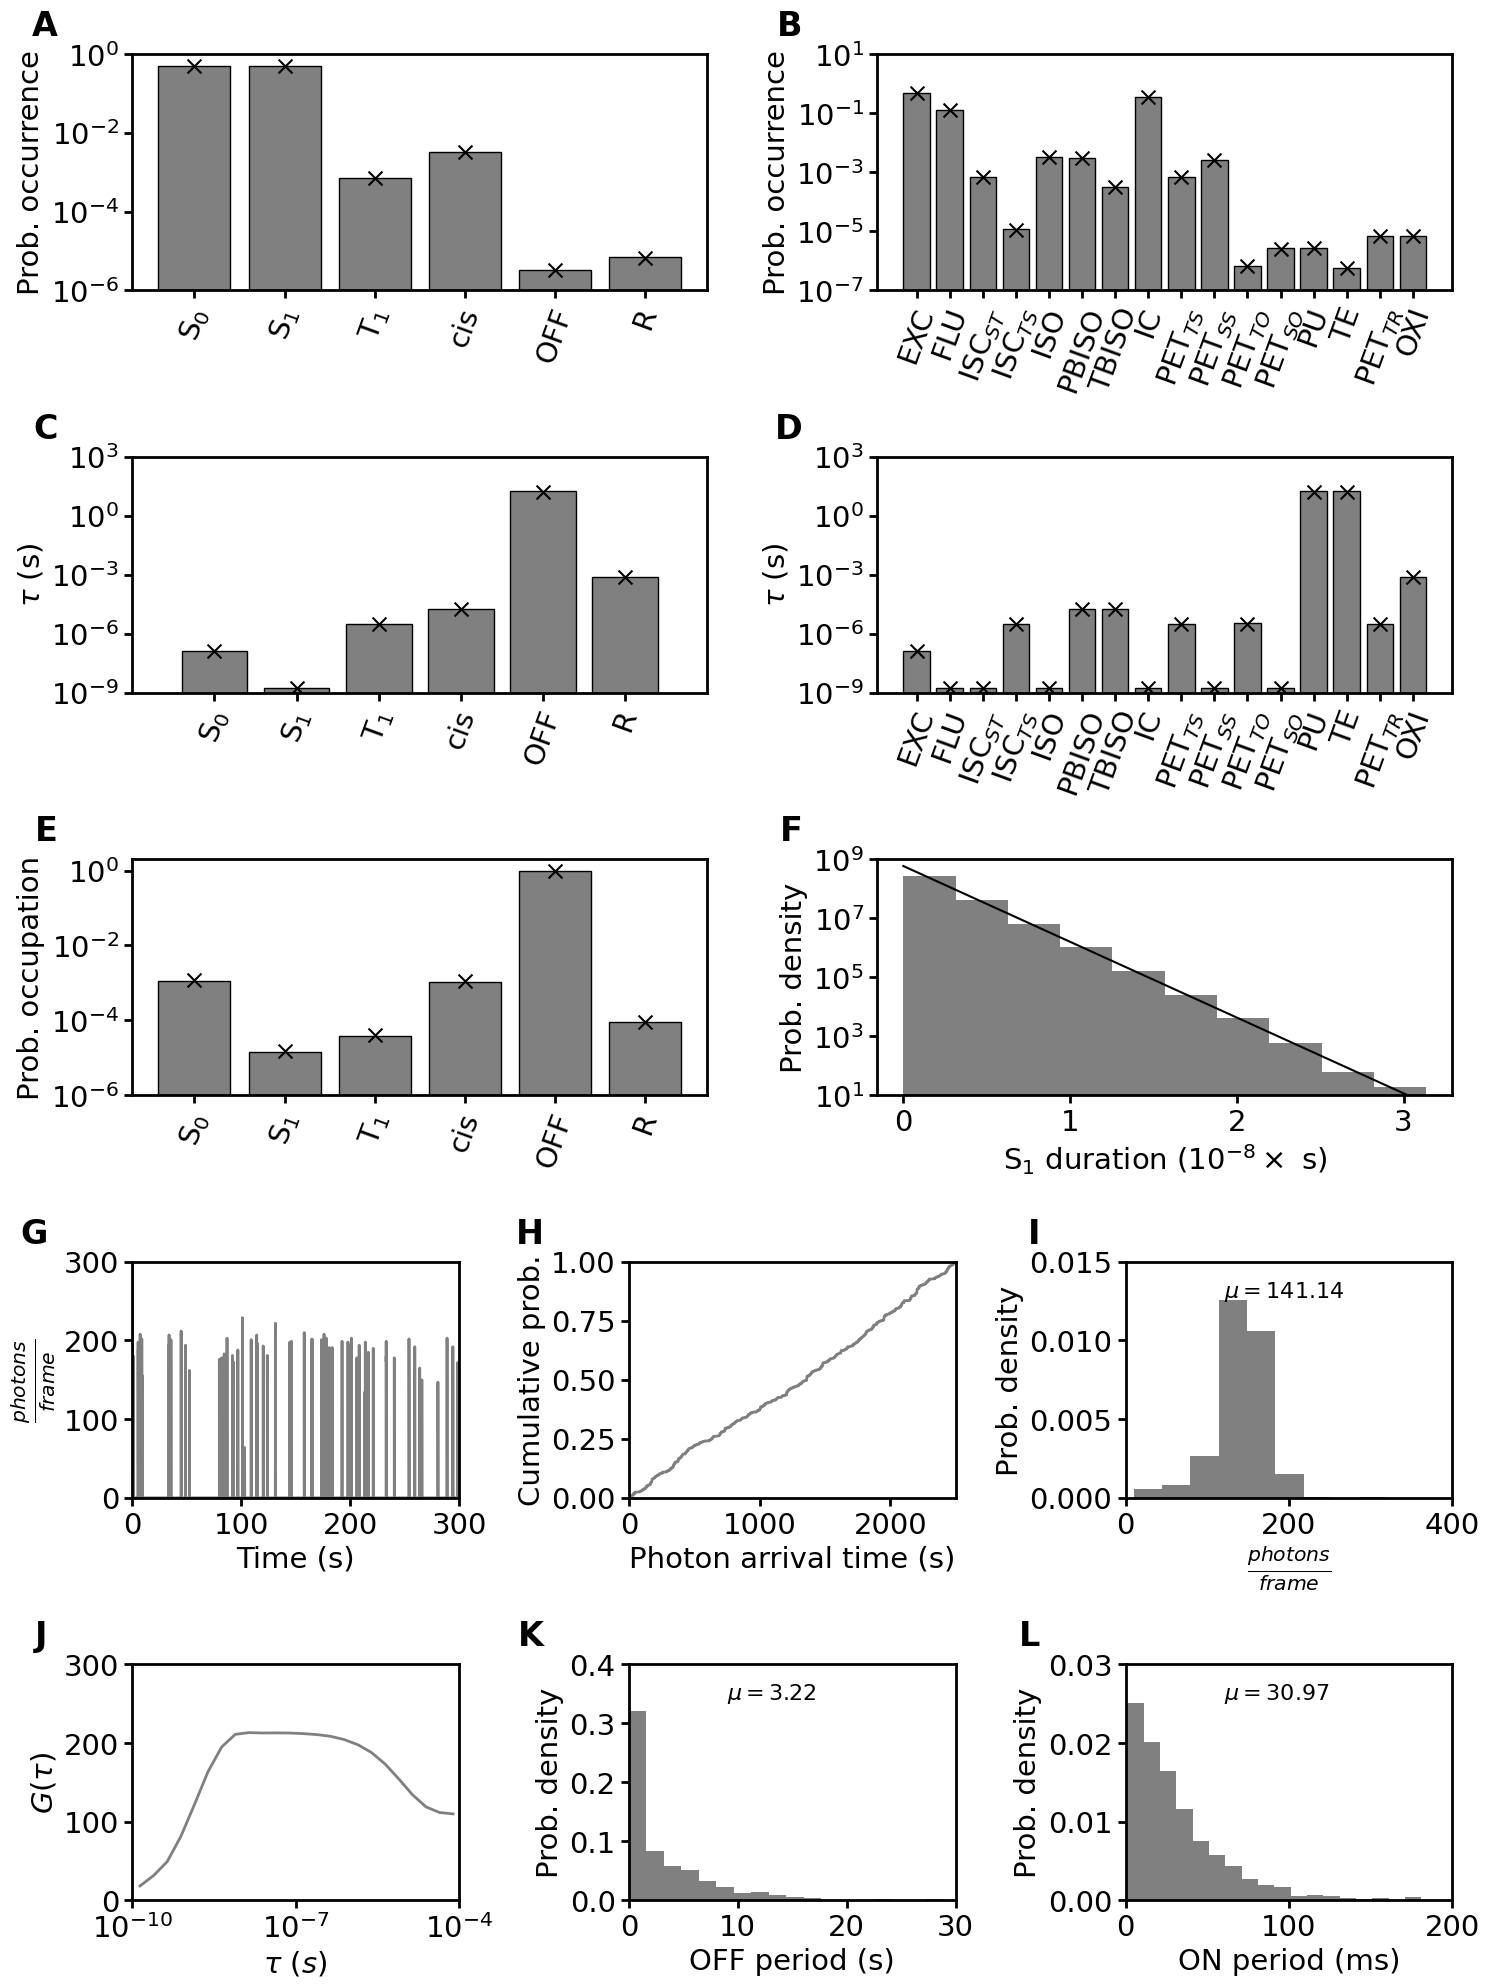

: 

In [ ]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(5, 6)
fig = plt.figure(figsize=(15, 20))
color = "grey"
analysis_plot_param = dict(
    legend=False,
    prediction=predict,
    color=color,
    # legendhandles=None,
    # legendargs=dict(framealpha=1, fontsize=16, edgecolor="black", fancybox=False),
)
ax = fig.add_subplot(gs[0, 0:3])
analysis.plot_frequency_states(ylim=[1e-6, 1e0], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[0, 3:])
analysis.plot_frequency_transitions(
    ylim=[1e-7, 1e1],
    axes=ax,
    **analysis_plot_param,
    yticks=[1e-7, 1e-5, 1e-3, 1e-1, 1e1],
)
ax = fig.add_subplot(gs[1, 0:3])
analysis.plot_mean_lifetimes(ylim=[1e-9, 1e3], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[1, 3:])
analysis.plot_mean_transition_times(ylim=[1e-9, 1e3], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[2, 0:3])
analysis.plot_state_occupations(ylim=[1e-6, 2e0], axes=ax, **analysis_plot_param)
ax = fig.add_subplot(gs[2, 3:])
analysis.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    **analysis_plot_param,
    title=None,
    ylim=[1e1, 1e9],
    tick_style_x="sci",
)

ax = fig.add_subplot(gs[3, 0:2])
emis.plot_time_series(
    axes=ax,
    color=color,
    xlim=[0, 300],
    ylim=[0, 300],
    lw=2,
)
ax = fig.add_subplot(gs[3, 2:4])
emis.plot_cumulative_events(
    axes=ax,
    color=color,
    xlim=[0, 2500],
    lw=2,
)
ax = fig.add_subplot(gs[3, 4:])
emis.plot_histogram(
    axes=ax,
    color=color,
    ylim=[0, 0.015],
    xlim=[0, 400],
    display_mean=True,
    bins=17,
)

ax = fig.add_subplot(gs[4, 0:2])
fcs.plot(
    axes=ax, unit="s", color=color, title=None, xlim=[1e-10, 1e-4], ylim=[0, 300], lw=2
)

ax = fig.add_subplot(gs[4, 2:4])
blink.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    color=color,
    xlim=[0, 30],
    ylim=[0, 0.4],
    bins=18,
)
ax = fig.add_subplot(gs[4, 4:])
blink.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    color=color,
    xlim=[0, 200],
    ylim=[0, 0.03],
    bins=18,
)
axes = fig.get_axes()
for i, (axis, letter) in enumerate(
    zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"])
):
    offset = -0.13
    if i > 5:
        offset = -0.26
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    saving_at + r"\4_f_no_et_statistics.png",
    dpi=300,
    bbox_inches=bbox,
)